In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

RANDOM_STATE = 42

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("../Datasets/manufacturing.csv")

In [3]:
df.shape

(3957, 6)

In [4]:
df.head()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB


In [6]:
pd.DataFrame({
    'missing_values': df.isnull().sum(),
    'missing_%' : (df.isnull().sum() / len(df) * 100).round(2),
})

,missing_values,missing_%
Temperature (°C),0,0.0
Pressure (kPa),0,0.0
Temperature x Pressure,0,0.0
Material Fusion Metric,0,0.0
Material Transformation Metric,0,0.0
Quality Rating,0,0.0


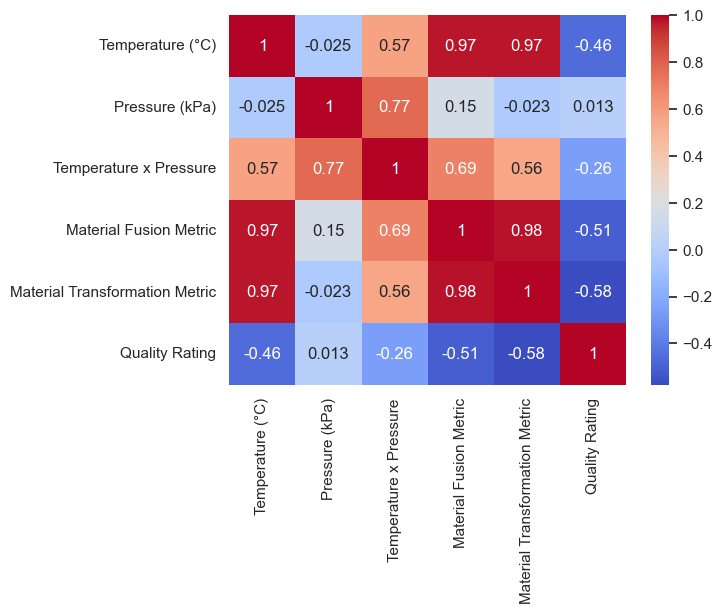

In [7]:
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

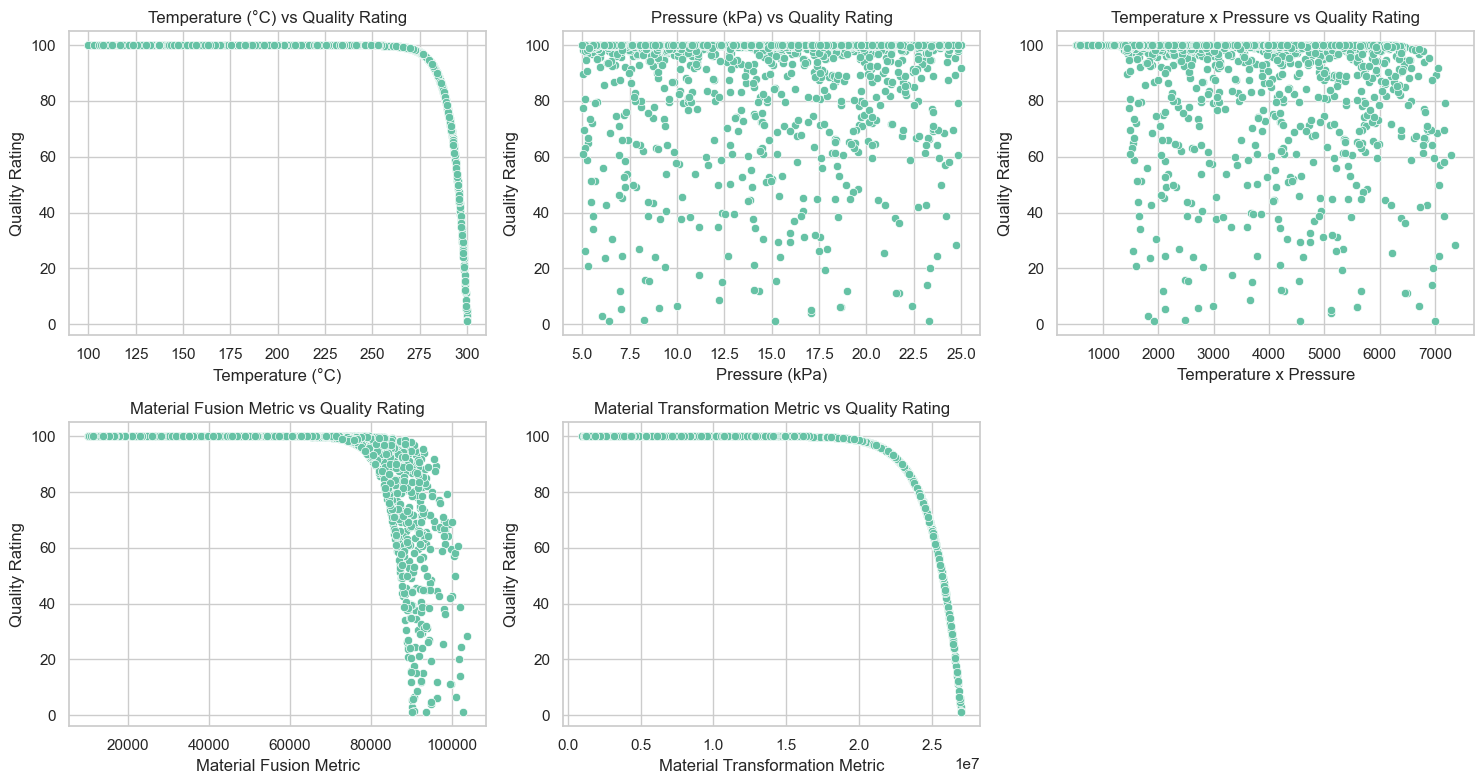

In [8]:
X = df.iloc[:, :-1]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.scatterplot(data=df, x=col, y='Quality Rating', ax=axes[i])
    axes[i].set_title(f'{col} vs Quality Rating')

for i in range(len(X.columns), len(axes)):
    fig.delaxes(axes[i])
    
plt.tight_layout()
plt.show()

## Model Training

In [9]:
X = df.iloc[:, :-1]
y = df['Quality Rating']

In [10]:
X.head()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06


In [11]:
y.head()

0     99.999971
1     99.985703
2     99.999758
3     99.999975
4    100.000000
Name: Quality Rating, dtype: float64

In [12]:
print(X.shape)
print(y.shape)

(3957, 5)
(3957,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE
)

In [14]:
## implementing linear regression first
## the we will compare the r2 score of LR with Poly LR
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

print("Model trained.")

Model trained.


In [15]:
regression_1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
print("Intercept:", regression_1.intercept_)
print("Coefficient:", regression_1.coef_)

Intercept: 73.00372387543943
Coefficient: [ 2.34145840e-01 -6.26961483e-01  8.54992415e-04  6.49901962e-04
 -4.77783502e-06]


In [17]:
y_lr_pred = regression_1.predict(X_test)

In [18]:
score = r2_score(y_test, y_lr_pred)
print(f"Linear Regression r2_score = {score}")

Linear Regression r2_score = 0.5205300868591256


In [23]:
def poly_regression(degree):
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)

    print("Model trained.")
    print("Intercept:", pipeline.named_steps['model'].intercept_)
    print("\n")
    
    # features = pipeline.named_steps['poly'].get_feature_names_out(X_train.columns)
    # coefficients = pipeline.named_steps['model'].coef_
    
    # for feature, coef in zip(features, coefficients):
    #     print(f"{feature}: {coef}")
        
    print("\n")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
    print("R²:", r2_score(y_test, y_pred))


In [24]:
poly_regression(2)

Model trained.
Intercept: 96.38197144355384




MAE: 2.429683726250912
RMSE: 3.725133327223335
R²: 0.9302292471868445
